<a href="https://colab.research.google.com/github/KeerthanaSistla/Sem6DeepLearning/blob/main/DLAssignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
422/422 - 12s - 29ms/step - accuracy: 0.7991 - loss: 1.0576 - val_accuracy: 0.8447 - val_loss: 0.7276
Epoch 2/50
422/422 - 2s - 6ms/step - accuracy: 0.8438 - loss: 0.6677 - val_accuracy: 0.8527 - val_loss: 0.5816
Epoch 3/50
422/422 - 1s - 3ms/step - accuracy: 0.8516 - loss: 0.5685 - val_accuracy: 0.8618 - val_loss: 0.5243
Epoch 4/50
422/422 - 1s - 3ms/step - accuracy: 0.8552 - loss: 0.5262 - val_accuracy: 0.8697 - val_loss: 0.4905
Epoch 5/50
422/422 - 1s - 3ms/step - accuracy: 0.8581 - loss: 0.5101 - val_accuracy: 0.8648 - val_loss: 0.4912
Epoch 6/50
422/422 - 2s - 4ms/step - accuracy: 0.8630 - loss: 0.4863 - val_accuracy: 0.8628 - val_loss: 0.4774
Epoch 7/50
422/422 - 1s - 3ms/step - accuracy: 0.8623 - loss: 0.4824 - val_accuracy: 0.8612 - val_loss: 0.4818
Epoch 8/50
422/422 - 1s - 3ms/step - accuracy: 0.8648 - loss: 0.4763 - val_accuracy: 0.8643 - val_loss: 0.4695
Epoch 9/50
422/422 - 1s - 3ms/step - accuracy: 0.8642 - loss: 0.4710 - val_accuracy: 0.8665 - val_loss: 0.4698

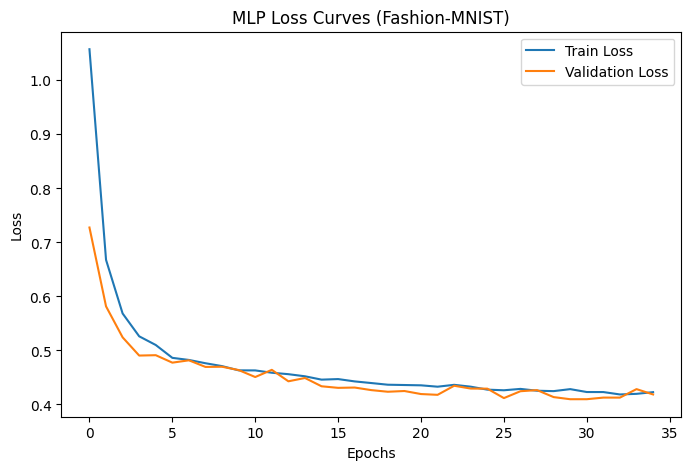

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# =========================
# Load Fashion-MNIST
# =========================
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train.reshape(-1, 28*28) / 255.0
X_test = X_test.reshape(-1, 28*28) / 255.0

# =========================
# Early stopping
# =========================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# =========================
# Create MLP model
# =========================
def create_mlp_model(dropout_rate=0.0, l2=0.0):
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(28*28,),
                     kernel_regularizer=regularizers.l2(l2)),
        layers.Dropout(dropout_rate),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2)),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# =========================
# Train model with L2 + Dropout
# =========================
model = create_mlp_model(dropout_rate=0.2, l2=0.001)
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=2
)

# =========================
# Evaluate
# =========================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)

# =========================
# Plot loss curves
# =========================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MLP Loss Curves (Fashion-MNIST)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (48000, 784)
Validation set: (12000, 784)
Test set: (10000, 784)

Original training samples: 1000
Augmented training samples: 4000

1. TRAINING WITH DATA AUGMENTATION


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6917 - loss: 0.8624 - val_accuracy: 0.7632 - val_loss: 0.6909
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8163 - loss: 0.5313 - val_accuracy: 0.7927 - val_loss: 0.6483
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8445 - loss: 0.4202 - val_accuracy: 0.7821 - val_loss: 0.6302
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8700 - loss: 0.3561 - val_accuracy: 0.7830 - val_loss: 0.6291
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8915 - loss: 0.3038 - val_accuracy: 0.8061 - val_loss: 0.5894
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9013 - loss: 0.2794 - val_accuracy: 0.7989 - val_loss: 0.6372
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9112 - loss: 0.2412 - val_accuracy: 0.7895 - val_loss: 0.7005
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9273 - loss: 0.1981 - val_accuracy: 

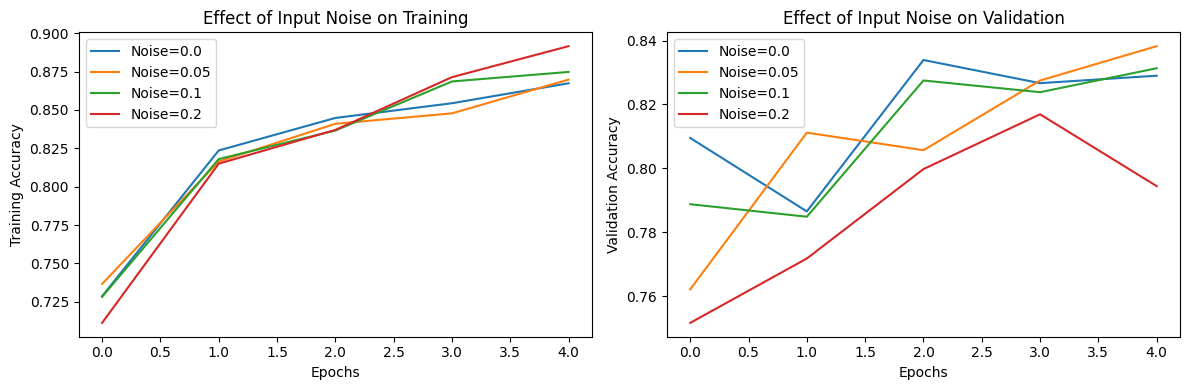


4. ENSEMBLE METHODS

Training model 1/5

Training model 2/5

Training model 3/5

Training model 4/5

Training model 5/5

Ensemble accuracy: 0.8366
Model 1 accuracy: 0.8428
Model 2 accuracy: 0.8093
Model 3 accuracy: 0.8281
Model 4 accuracy: 0.8183
Model 5 accuracy: 0.8084

5. REGULARIZATION TECHNIQUES COMPARISON

Training with none...

Training with l2_0.001...

Training with dropout_0.3...

Training with noise_0.1...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


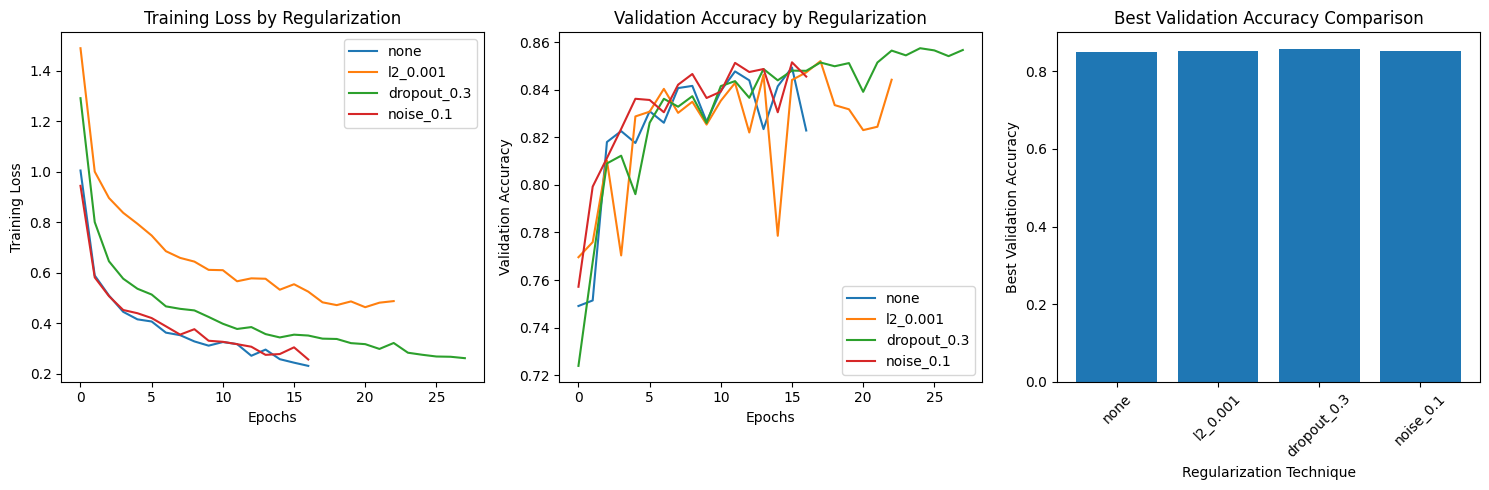

In [ ]:
# Regularization Techniques

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, datasets
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import itertools

# Load and prepare data
(X_train_full, y_train_full), (X_test, y_test) = datasets.fashion_mnist.load_data()
X_train_full = X_train_full.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0

# Split training into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# ============================================
# 1. Dataset Augmentation
# ============================================
def augment_data(X, y, noise_factor=0.05, rotation_range=10):
    """Simple data augmentation by adding noise and simple transformations"""
    augmented_X = []
    augmented_y = []

    for i in range(len(X)):
        # Original
        augmented_X.append(X[i])
        augmented_y.append(y[i])

        # Add Gaussian noise
        noise = np.random.normal(0, noise_factor, X[i].shape)
        noisy_sample = np.clip(X[i] + noise, 0, 1)
        augmented_X.append(noisy_sample)
        augmented_y.append(y[i])

        # Simple "rotation" by shifting pixels (simplified)
        shifted = np.roll(X[i].reshape(28, 28), shift=1, axis=0).flatten()
        augmented_X.append(shifted)
        augmented_y.append(y[i])

        # Horizontal flip approximation
        flipped = X[i].reshape(28, 28)[:, ::-1].flatten()
        augmented_X.append(flipped)
        augmented_y.append(y[i])

    return np.array(augmented_X), np.array(augmented_y)

# Augment training data
X_train_aug, y_train_aug = augment_data(X_train[:1000], y_train[:1000])  # Use subset for speed
y_train_aug_cat = to_categorical(y_train_aug, 10)

print(f"\nOriginal training samples: 1000")
print(f"Augmented training samples: {len(X_train_aug)}")

# Train with augmented data
def create_model():
    model = models.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("\n" + "="*50)
print("1. TRAINING WITH DATA AUGMENTATION")
print("="*50)
model_aug = create_model()
history_aug = model_aug.fit(
    X_train_aug, y_train_aug_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val_cat),
    verbose=1
)

# ============================================
# 2. Parameter Sharing and Tying (using Siamese network concept)
# ============================================
print("\n" + "="*50)
print("2. PARAMETER SHARING AND TYING")
print("="*50)

class SharedLayer(tf.keras.layers.Layer):
    """Custom layer with shared weights"""
    def __init__(self, units, activation=None):
        super(SharedLayer, self).__init__()
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.kernel = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.bias = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        return self.activation(tf.matmul(inputs, self.kernel) + self.bias)

# Create model with shared weights between two branches
input1 = layers.Input(shape=(784,))
input2 = layers.Input(shape=(784,))

shared_layer = SharedLayer(128, activation='relu')
shared_layer2 = SharedLayer(64, activation='relu')

# First branch
x1 = shared_layer(input1)
x1 = shared_layer2(x1)
x1 = layers.Dense(10, activation='softmax')(x1)

# Second branch (using same shared layers)
x2 = shared_layer(input2)
x2 = shared_layer2(x2)
x2 = layers.Dense(10, activation='softmax')(x2)

# Combined model (for demonstration, we'll use first branch)
model_shared = models.Model(inputs=input1, outputs=x1)
model_shared.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

print("\nParameter sharing demonstration:")
print(f"Total parameters with sharing: {model_shared.count_params():,}")
history_shared = model_shared.fit(
    X_train[:5000], y_train_cat[:5000],
    epochs=5,
    validation_data=(X_val, y_val_cat),
    verbose=1
)

# ============================================
# 3. Adding Noise to Inputs and Outputs
# ============================================
print("\n" + "="*50)
print("3. ADDING NOISE TO INPUTS AND OUTPUTS")
print("="*50)

def add_noise_to_inputs(X, noise_factor=0.1):
    """Add Gaussian noise to inputs"""
    noise = np.random.normal(0, noise_factor, X.shape)
    return np.clip(X + noise, 0, 1)

def add_noise_to_labels(y, noise_level=0.1):
    """Add label smoothing (noise to outputs)"""
    return y * (1 - noise_level) + noise_level / y.shape[1]

# Create models with different noise levels
noise_levels = [0.0, 0.05, 0.1, 0.2]
histories_noise = {}

for noise in noise_levels:
    print(f"\nTraining with noise level: {noise}")

    # Add noise to inputs
    X_train_noisy = add_noise_to_inputs(X_train[:5000], noise)

    # Add label smoothing
    y_train_noisy = add_noise_to_labels(y_train_cat[:5000], noise * 0.5)

    model_noise = create_model()
    history = model_noise.fit(
        X_train_noisy, y_train_noisy,
        epochs=5,
        validation_data=(X_val, y_val_cat),
        verbose=0
    )
    histories_noise[noise] = history.history

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for noise, hist in histories_noise.items():
    plt.plot(hist['accuracy'], label=f'Noise={noise}')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title('Effect of Input Noise on Training')
plt.legend()

plt.subplot(1, 2, 2)
for noise, hist in histories_noise.items():
    plt.plot(hist['val_accuracy'], label=f'Noise={noise}')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Input Noise on Validation')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# 4. Ensemble Methods
# ============================================
print("\n" + "="*50)
print("4. ENSEMBLE METHODS")
print("="*50)

# Train multiple models with different initializations
n_models = 5
models_ensemble = []

for i in range(n_models):
    print(f"\nTraining model {i+1}/{n_models}")
    model = create_model()
    history = model.fit(
        X_train[:5000], y_train_cat[:5000],
        epochs=5,
        validation_data=(X_val, y_val_cat),
        verbose=0
    )
    models_ensemble.append(model)

# Make predictions with ensemble
def ensemble_predict(models, X):
    """Average predictions from all models"""
    predictions = np.array([model.predict(X, verbose=0) for model in models])
    return np.mean(predictions, axis=0)

# Compare individual vs ensemble performance
y_pred_ensemble = ensemble_predict(models_ensemble, X_val)
y_pred_ensemble_classes = np.argmax(y_pred_ensemble, axis=1)
ensemble_accuracy = np.mean(y_pred_ensemble_classes == y_val)

print(f"\nEnsemble accuracy: {ensemble_accuracy:.4f}")

# Individual model accuracies
for i, model in enumerate(models_ensemble):
    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    acc = np.mean(y_pred == y_val)
    print(f"Model {i+1} accuracy: {acc:.4f}")

# ============================================
# 5. Combined Regularization Comparison
# ============================================
print("\n" + "="*50)
print("5. REGULARIZATION TECHNIQUES COMPARISON")
print("="*50)

def create_regularized_model(technique='none', rate=0.0):
    """Create model with specified regularization"""
    if technique == 'l2':
        model = models.Sequential([
            layers.Dense(256, activation='relu', input_shape=(784,),
                        kernel_regularizer=regularizers.l2(rate)),
            layers.Dense(128, activation='relu',
                        kernel_regularizer=regularizers.l2(rate)),
            layers.Dense(10, activation='softmax')
        ])
    elif technique == 'dropout':
        model = models.Sequential([
            layers.Dense(256, activation='relu', input_shape=(784,)),
            layers.Dropout(rate),
            layers.Dense(128, activation='relu'),
            layers.Dropout(rate),
            layers.Dense(10, activation='softmax')
        ])
    elif technique == 'noise':
        model = models.Sequential([
            layers.GaussianNoise(rate, input_shape=(784,)),
            layers.Dense(256, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])
    else:  # no regularization
        model = models.Sequential([
            layers.Dense(256, activation='relu', input_shape=(784,)),
            layers.Dense(128, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Train with different regularization techniques
techniques = {
    'none': {'technique': 'none', 'rate': 0},
    'l2_0.001': {'technique': 'l2', 'rate': 0.001},
    'dropout_0.3': {'technique': 'dropout', 'rate': 0.3},
    'noise_0.1': {'technique': 'noise', 'rate': 0.1}
}

histories_reg = {}
val_accuracies = {}

for name, params in techniques.items():
    print(f"\nTraining with {name}...")
    model = create_regularized_model(params['technique'], params['rate'])

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train[:5000], y_train_cat[:5000],
        epochs=30,
        batch_size=128,
        validation_data=(X_val, y_val_cat),
        callbacks=[early_stop],
        verbose=0
    )

    histories_reg[name] = history.history
    val_accuracies[name] = max(history.history['val_accuracy'])

# Plot comparison
plt.figure(figsize=(15, 5))

# Training loss
plt.subplot(1, 3, 1)
for name, hist in histories_reg.items():
    plt.plot(hist['loss'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Training Loss by Regularization')
plt.legend()

# Validation accuracy
plt.subplot(1, 3, 2)
for name, hist in histories_reg.items():
    plt.plot(hist['val_accuracy'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy by Regularization')
plt.legend()

# Bar plot of best validation accuracy
plt.subplot(1, 3, 3)
names = list(val_accuracies.keys())
values = list(val_accuracies.values())
plt.bar(names, values)
plt.xlabel('Regularization Technique')
plt.ylabel('Best Validation Accuracy')
plt.title('Best Validation Accuracy Comparison')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

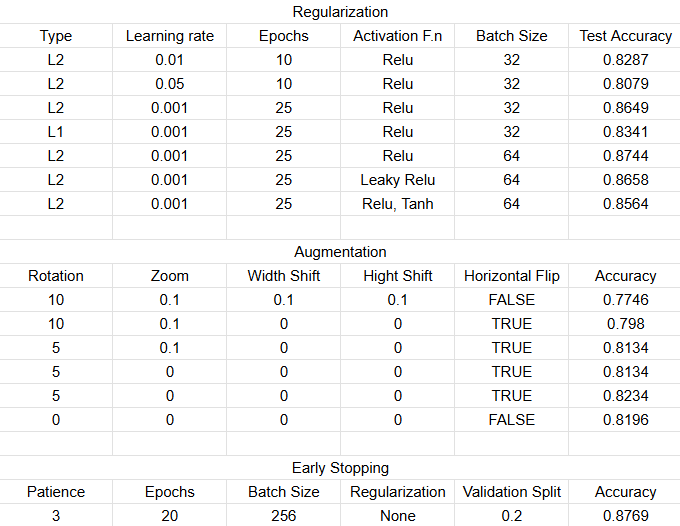

CNN ON FASHION MNIST
Training data: (60000, 28, 28, 1)
Test data: (10000, 28, 28, 1)


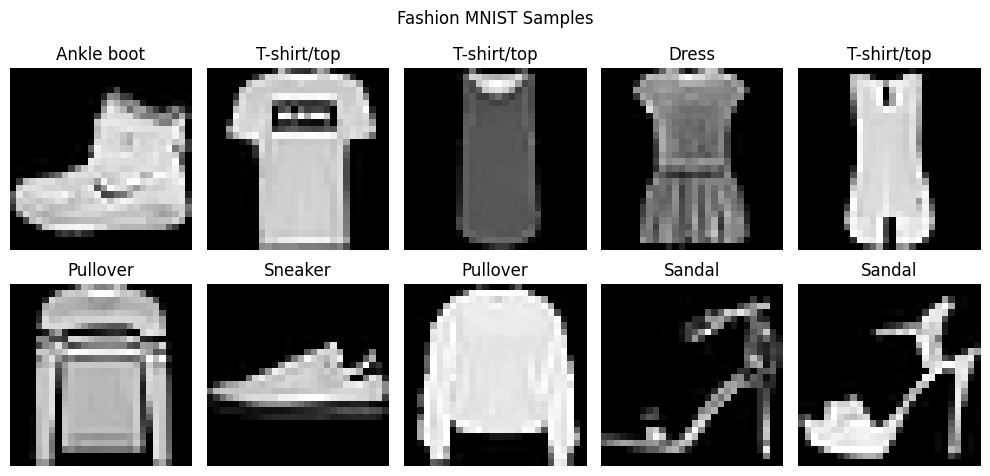


BUILDING SIMPLE CNN


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING CNN
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7719 - loss: 0.6284 - val_accuracy: 0.8355 - val_loss: 0.4324
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8588 - loss: 0.3895 - val_accuracy: 0.8715 - val_loss: 0.3557
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8776 - loss: 0.3363 - val_accuracy: 0.8833 - val_loss: 0.3269
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8915 - loss: 0.3018 - val_accuracy: 0.8833 - val_loss: 0.3204
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9016 - loss: 0.2747 - val_accuracy: 0.8902 - val_loss: 0.3019
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9063 - loss: 0.2574 - val_accuracy: 0.9012 - val_loss: 0.2708
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9119 - loss: 0.2420 - val_accuracy: 0.9012 - val_loss: 0.2765
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9171 - loss: 0.2260 - 

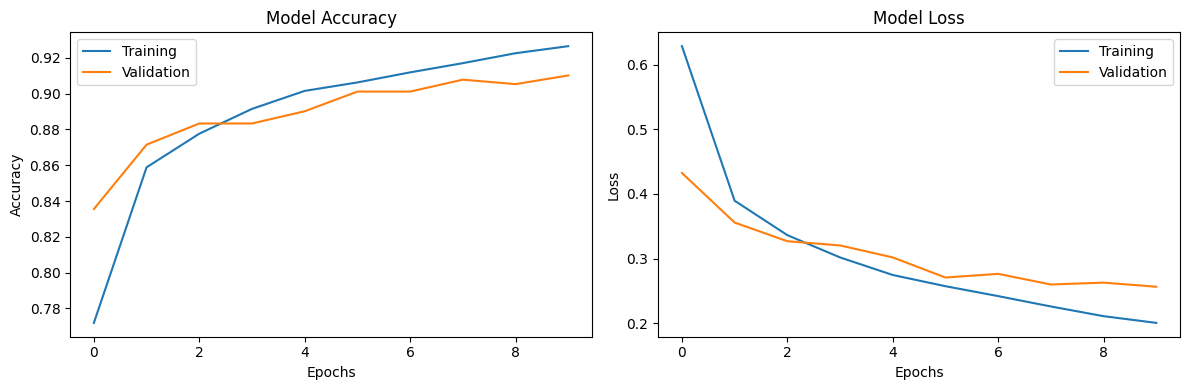


TESTING WITH SAMPLE IMAGES
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step


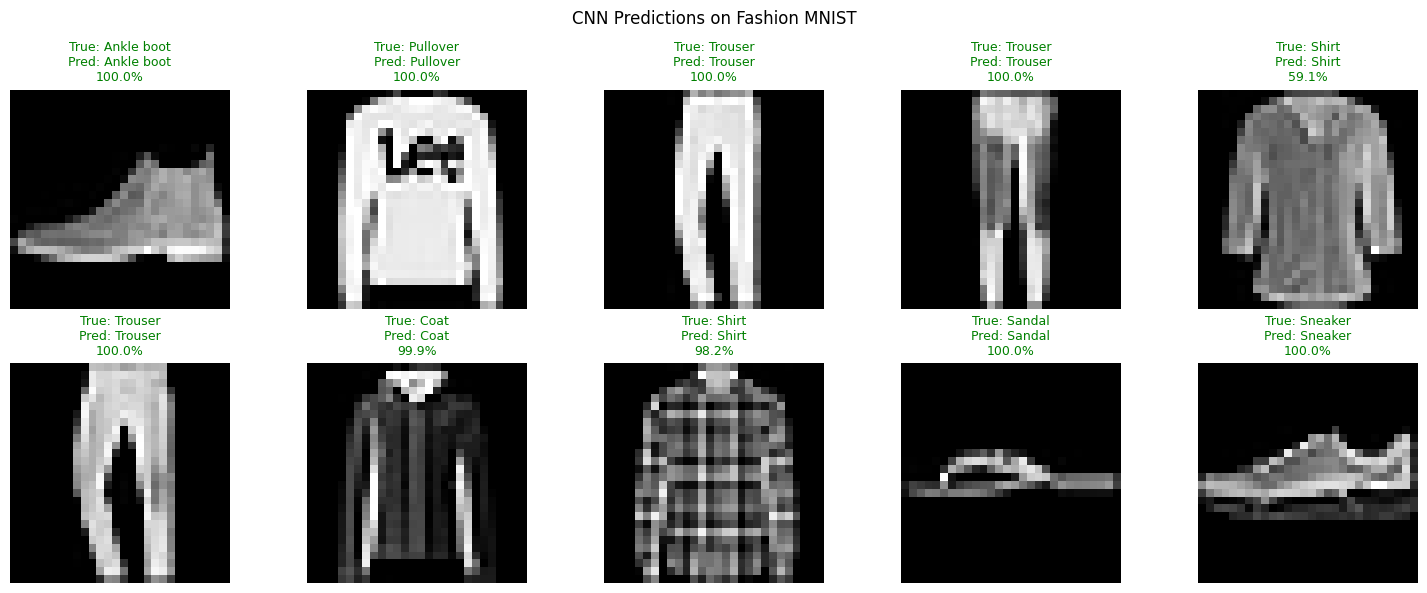


TRYING DIFFERENT LEARNING RATES

Training with learning rate: 0.1
Best validation accuracy: 0.1020

Training with learning rate: 0.01
Best validation accuracy: 0.8360

Training with learning rate: 0.001
Best validation accuracy: 0.8040

Training with learning rate: 0.0001
Best validation accuracy: 0.6960


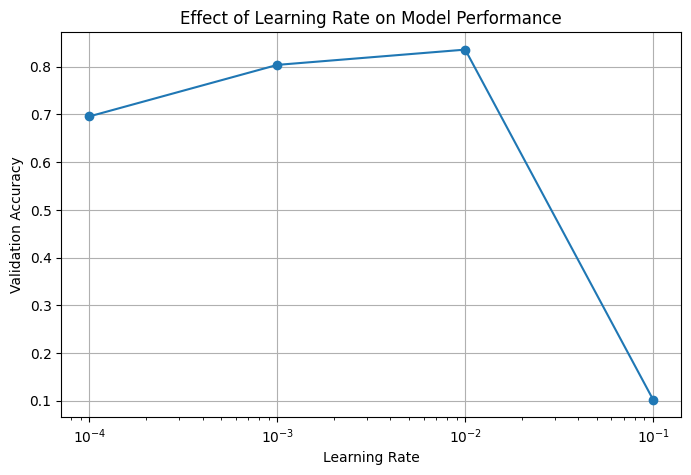


Best learning rate: 0.01


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, datasets

# ============================================
# 1. LOAD FASHION MNIST
# ============================================
print("="*60)
print("CNN ON FASHION MNIST")
print("="*60)

# Load data
(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Preprocess
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")

# Show samples
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.suptitle('Fashion MNIST Samples')
plt.tight_layout()
plt.show()

# ============================================
# 2. SIMPLE CNN MODEL
# ============================================
print("\n" + "="*60)
print("BUILDING SIMPLE CNN")
print("="*60)

model = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

# ============================================
# 3. TRAIN THE MODEL
# ============================================
print("\n" + "="*60)
print("TRAINING CNN")
print("="*60)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# ============================================
# 4. EVALUATE
# ============================================
print("\n" + "="*60)
print("EVALUATION")
print("="*60)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ============================================
# 5. TEST WITH SAMPLE
# ============================================
print("\n" + "="*60)
print("TESTING WITH SAMPLE IMAGES")
print("="*60)

# Make predictions
predictions = model.predict(X_test[:10])

# Show results
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    true_label = class_names[np.argmax(y_test[i])]
    pred_label = class_names[np.argmax(predictions[i])]
    confidence = np.max(predictions[i]) * 100

    color = 'green' if true_label == pred_label else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label}\n{confidence:.1f}%',
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('CNN Predictions on Fashion MNIST')
plt.tight_layout()
plt.show()

# ============================================
# 6. TRY DIFFERENT PARAMETERS
# ============================================
print("\n" + "="*60)
print("TRYING DIFFERENT LEARNING RATES")
print("="*60)

learning_rates = [0.1, 0.01, 0.001, 0.0001]
results = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")

    # Create new model
    model_lr = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    # Use different optimizer with specific learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model_lr.compile(optimizer=optimizer,
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

    # Train briefly
    history_lr = model_lr.fit(
        X_train[:10000], y_train[:10000],  # Use subset for speed
        epochs=3,
        batch_size=128,
        validation_split=0.1,
        verbose=0
    )

    val_acc = max(history_lr.history['val_accuracy'])
    results[lr] = val_acc
    print(f"Best validation accuracy: {val_acc:.4f}")

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(list(results.keys()), list(results.values()), 'o-')
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Learning Rate on Model Performance')
plt.grid(True)
plt.show()

print("\nBest learning rate:", max(results, key=results.get))

LeNet

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7519 - loss: 0.6771 - val_accuracy: 0.7890 - val_loss: 0.5373
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8240 - loss: 0.4791 - val_accuracy: 0.8372 - val_loss: 0.4379
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8455 - loss: 0.4259 - val_accuracy: 0.8450 - val_loss: 0.4095
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8575 - loss: 0.3909 - val_accuracy: 0.8517 - val_loss: 0.3922
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8646 - loss: 0.3683 - val_accuracy: 0.8595 - val_loss: 0.3783
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8725 - loss: 0.3463 - val_accuracy: 0.8695 - val_loss: 0.3555
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s

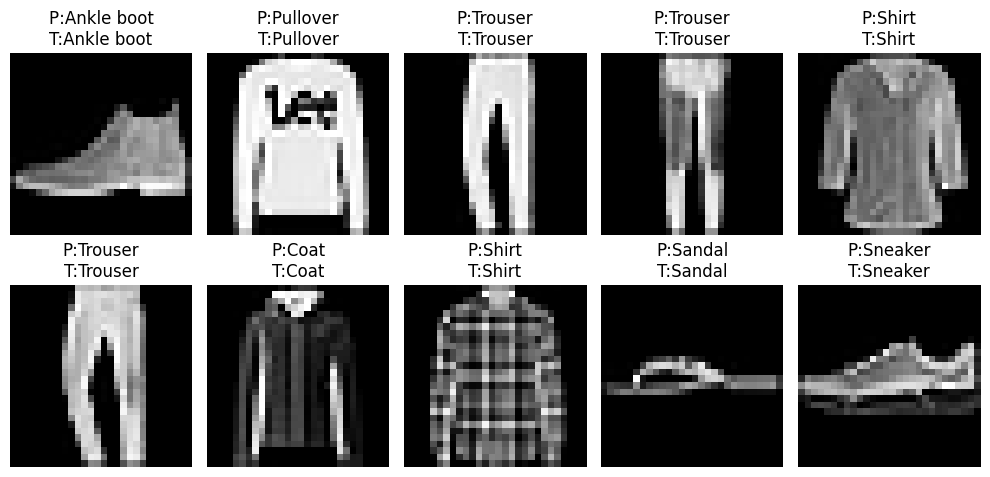

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD FASHION MNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. PREPROCESS
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# 3. LENET-5 MODEL
model = Sequential([
    Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1)),
    AveragePooling2D((2, 2)),
    Conv2D(16, (5, 5), activation='tanh'),
    AveragePooling2D((2, 2)),
    Flatten(),
    Dense(120, activation='tanh'),
    Dense(84, activation='tanh'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. TRAIN
model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

# 5. EVALUATE
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

# 6. VISUALIZE PREDICTIONS
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    pred = np.argmax(model.predict(x_test[i].reshape(1, 28, 28, 1)))
    true = np.argmax(y_test[i])

    plt.title(f"P:{class_names[pred]}\nT:{class_names[true]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# 1. LOAD FASHION MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape (grayscale)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# MODEL DEFINITIONS

# LeNet-1 (very shallow)
def LeNet1():
    model = Sequential([
        Conv2D(4, (5, 5), activation='tanh', input_shape=(28, 28, 1)),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(10, activation='softmax')
    ])
    return model

# LeNet-2
def LeNet2():
    model = Sequential([
        Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1)),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(50, activation='tanh'),
        Dense(10, activation='softmax')
    ])
    return model

# LeNet-3
def LeNet3():
    model = Sequential([
        Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1)),
        AveragePooling2D((2, 2)),
        Conv2D(16, (5, 5), activation='tanh'),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(84, activation='tanh'),
        Dense(10, activation='softmax')
    ])
    return model

# LeNet-4 (almost LeNet-5 but smaller FC)
def LeNet4():
    model = Sequential([
        Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1)),
        AveragePooling2D((2, 2)),
        Conv2D(16, (5, 5), activation='tanh'),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(120, activation='tanh'),
        Dense(10, activation='softmax')
    ])
    return model

# TRAIN & EVALUATE FUNCTION
def train_model(model_fn, name):
    print(f"\nTraining {name}...")

    model = model_fn()

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{name} Test Accuracy: {acc:.4f}")

    return history, acc

# RUN ALL MODELS
results = {}

for model_fn, name in [
    (LeNet1, "LeNet-1"),
    (LeNet2, "LeNet-2"),
    (LeNet3, "LeNet-3"),
    (LeNet4, "LeNet-4")
]:
    history, acc = train_model(model_fn, name)
    results[name] = acc

# SUMMARY
print("\nFinal Results:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


Training LeNet-1...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7147 - loss: 0.8140 - val_accuracy: 0.7947 - val_loss: 0.5646
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8071 - loss: 0.5316 - val_accuracy: 0.8210 - val_loss: 0.4826
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8322 - loss: 0.4691 - val_accuracy: 0.8368 - val_loss: 0.4392
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8454 - loss: 0.4372 - val_accuracy: 0.8452 - val_loss: 0.4241
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8526 - loss: 0.4167 - val_accuracy: 0.8532 - val_loss: 0.4113
LeNet-1 Test Accuracy: 0.8419

Training LeNet-2...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7856 - loss: 0.6197 - val_accuracy: 0.8318 - val_loss: 0.4623
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8451 - loss: 0.4348 - val_accuracy: 0.8490 - val_loss: 0.4055
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━


Running: Baseline (tanh, Adam)
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.7506 - loss: 0.6641 - val_accuracy: 0.8218 - val_loss: 0.4800
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8325 - loss: 0.4585 - val_accuracy: 0.8362 - val_loss: 0.4484
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8543 - loss: 0.4004 - val_accuracy: 0.8548 - val_loss: 0.3932
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8643 - loss: 0.3706 - val_accuracy: 0.8585 - val_loss: 0.3739
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8730 - loss: 0.3465 - val_accuracy: 0.8512 - val_loss: 0.3956
Test Accuracy: 0.8455

Running: ReLU Activation
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7047 - loss: 0.7771 - val_accuracy: 0.7815 - val_loss: 0.5658
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8028 - loss: 0.5222 - val_accuracy: 0.8040 - val_loss: 0.5078
Epoch 3/5
422/422 ━━━━━━━━━

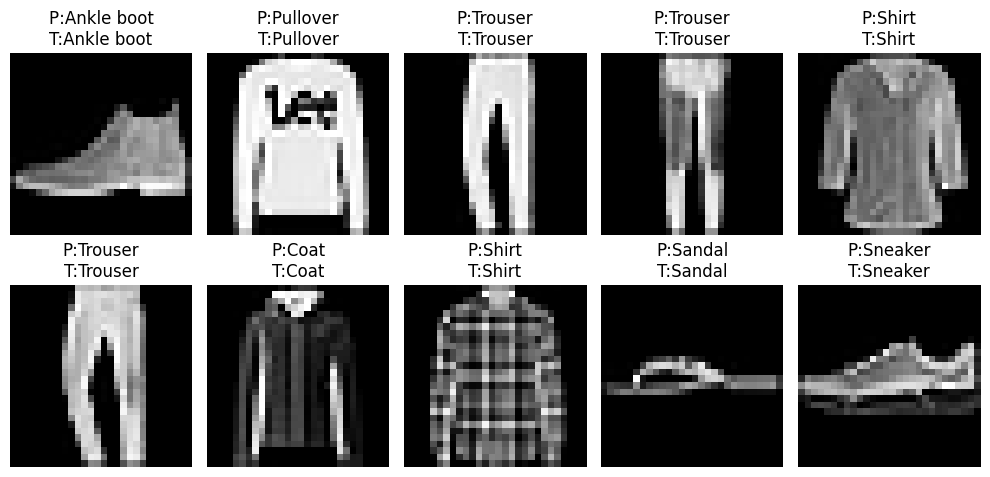

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout
from keras.datasets import fashion_mnist
from keras.optimizers import Adam, SGD
import numpy as np
import matplotlib.pyplot as plt

# LOAD DATA
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# PREPROCESS
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# CLASS NAMES
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# FUNCTION TO BUILD MODEL
def build_lenet(activation='tanh', use_dropout=False):
    model = Sequential([
        Conv2D(6, (5, 5), activation=activation, input_shape=(28, 28, 1)),
        AveragePooling2D((2, 2)),
        Conv2D(16, (5, 5), activation=activation),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(120, activation=activation),
        Dropout(0.5) if use_dropout else Dense(120, activation=activation),
        Dense(84, activation=activation),
        Dense(10, activation='softmax')
    ])
    return model

# EXPERIMENT SETTINGS
experiments = [
    {"name": "Baseline (tanh, Adam)", "activation": "tanh", "optimizer": Adam(), "lr": 0.001, "dropout": False, "batch":128},
    {"name": "ReLU Activation", "activation": "relu", "optimizer": Adam(), "lr": 0.001, "dropout": False, "batch":128},
    {"name": "Low LR", "activation": "relu", "optimizer": Adam(learning_rate=0.0001), "lr": 0.0001, "dropout": False, "batch":128},
    {"name": "With Dropout", "activation": "relu", "optimizer": Adam(), "lr": 0.001, "dropout": True, "batch":128},
    {"name": "SGD Optimizer", "activation": "relu", "optimizer": SGD(learning_rate=0.01), "lr": 0.01, "dropout": False, "batch":128},
    {"name": "Small Batch", "activation": "relu", "optimizer": Adam(), "lr": 0.001, "dropout": False, "batch":64},
]

results = []

# RUN EXPERIMENTS
for exp in experiments:
    print("\nRunning:", exp["name"])

    model = build_lenet(exp["activation"], exp["dropout"])

    model.compile(
        optimizer=exp["optimizer"],
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=exp["batch"],
        validation_split=0.1,
        verbose=1
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results.append((exp["name"], acc))
    print(f"Test Accuracy: {acc:.4f}")

# PRINT RESULTS
print("\nFINAL RESULTS:")
for name, acc in results:
    print(f"{name}: {acc:.4f}")

# VISUALIZE BEST MODEL
best_exp = max(results, key=lambda x: x[1])
print("\nBest Model:", best_exp[0])

# Rebuild best model for predictions
best_model = build_lenet('relu')
best_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
best_model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)

# SHOW PREDICTIONS
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    pred = np.argmax(best_model.predict(x_test[i].reshape(1, 28, 28, 1), verbose=0))
    true = np.argmax(y_test[i])

    plt.title(f"P:{class_names[pred]}\nT:{class_names[true]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

AlexNet


Running: Baseline
Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 85s 10ms/step - accuracy: 0.7458 - loss: 0.6898 - val_accuracy: 0.8185 - val_loss: 0.4873
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 73s 10ms/step - accuracy: 0.8174 - loss: 0.5031 - val_accuracy: 0.8196 - val_loss: 0.4754
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 73s 10ms/step - accuracy: 0.8242 - loss: 0.4774 - val_accuracy: 0.8252 - val_loss: 0.4958
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.8289 - loss: 0.4707 - val_accuracy: 0.8161 - val_loss: 0.4682
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.8312 - loss: 0.4669 - val_accuracy: 0.8216 - val_loss: 0.4635
Test Accuracy: 0.8216000199317932

Running: Low LR
Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 130s 15ms/step - accuracy: 0.8239 - loss: 0.4748 - val_accuracy: 0.8759 - val_loss: 0.3467
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 109s 14ms/step - accuracy: 0.8932 - loss: 0.2929 - val_accuracy: 0.8909 - val_loss: 0.2995
Epoch 3/5
750

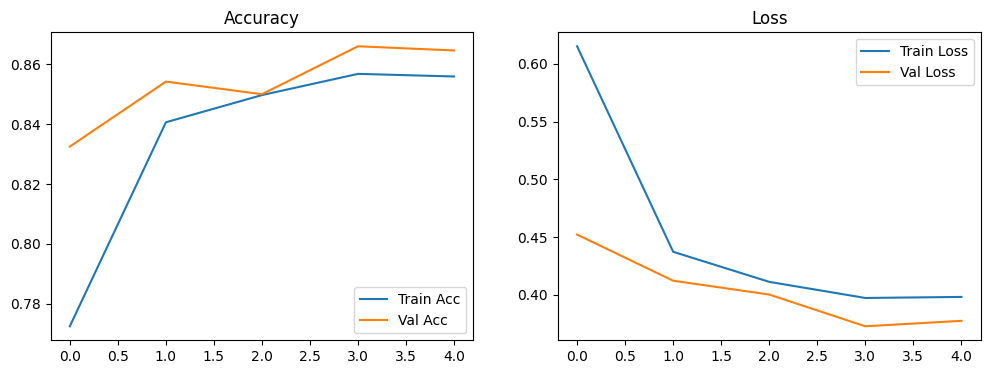

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc

# Clear session
keras.backend.clear_session()

# LOAD FASHION MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Expand dims
x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

# PREPROCESS FUNCTION
def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (112, 112))
    return image / 255.0, tf.one_hot(label, 10)

# DATA PIPELINE FUNCTION
def create_dataset(batch_size):
    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_ds = train_ds.map(process_image).batch(batch_size).shuffle(1000).prefetch(tf.data.AUTOTUNE)

    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
    test_ds = test_ds.map(process_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_ds, test_ds

# ENABLE MIXED PRECISION
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# MODEL BUILDER
def build_alexnet(dense_size=4096, dropout_rate=0.5):
    model = Sequential()

    model.add(Conv2D(96, (11,11), strides=(4,4), activation='relu', input_shape=(112,112,3)))
    model.add(MaxPooling2D((3,3), strides=(2,2)))

    model.add(Conv2D(256, (5,5), padding='same', activation='relu'))
    model.add(MaxPooling2D((3,3), strides=(2,2)))

    model.add(Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D((3,3), strides=(2,2)))

    model.add(Flatten())

    model.add(Dense(dense_size, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(dense_size, activation='relu'))
    model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    return model

# EXPERIMENT SETTINGS
experiments = [
    {"name": "Baseline", "lr":0.001, "batch":8, "dense":4096, "dropout":0.5},
    {"name": "Low LR", "lr":0.0001, "batch":8, "dense":4096, "dropout":0.5},
    {"name": "Small Dense", "lr":0.001, "batch":8, "dense":1024, "dropout":0.5},
    {"name": "Less Dropout", "lr":0.001, "batch":8, "dense":4096, "dropout":0.3},
    {"name": "Large Batch", "lr":0.001, "batch":16, "dense":4096, "dropout":0.5},
]

results = []

# RUN EXPERIMENTS
for exp in experiments:
    print("\nRunning:", exp["name"])

    train_ds, test_ds = create_dataset(exp["batch"])

    model = build_alexnet(exp["dense"], exp["dropout"])

    optimizer = keras.optimizers.Adam(learning_rate=exp["lr"])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(train_ds, epochs=5, validation_data=test_ds, verbose=1)

    loss, acc = model.evaluate(test_ds, verbose=0)
    print("Test Accuracy:", acc)

    results.append((exp["name"], acc))

    # Clear memory after each experiment
    keras.backend.clear_session()
    gc.collect()

# PRINT RESULTS
print("\nFINAL RESULTS:")
for name, acc in results:
    print(f"{name}: {acc:.4f}")

# PLOT LAST EXPERIMENT GRAPH
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

ZF-Net

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Running: Baseline


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 97s 9ms/step - accuracy: 0.0982 - loss: 2.3035 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 68s 9ms/step - accuracy: 0.0982 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 3/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step - accuracy: 0.0993 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3028
Test Accuracy: 0.10000000149011612

Running: Low LR
Epoch 1/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 158s 20ms/step - accuracy: 0.8250 - loss: 0.4819 - val_accuracy: 0.8874 - val_loss: 0.3076
Epoch 2/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 147s 19ms/step - accuracy: 0.8968 - loss: 0.2826 - val_accuracy: 0.9092 - val_loss: 0.2502
Epoch 3/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 147s 19ms/step - accuracy: 0.9159 - loss: 0.2297 - val_accuracy: 0.9196 - val_loss: 0.2389
Test Accuracy: 0.9196000099182129

Running: High LR
Epoch 1/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 148s 19ms/step - accuracy: 0.0987 - loss: 2.9649 - val_accuracy: 0.10

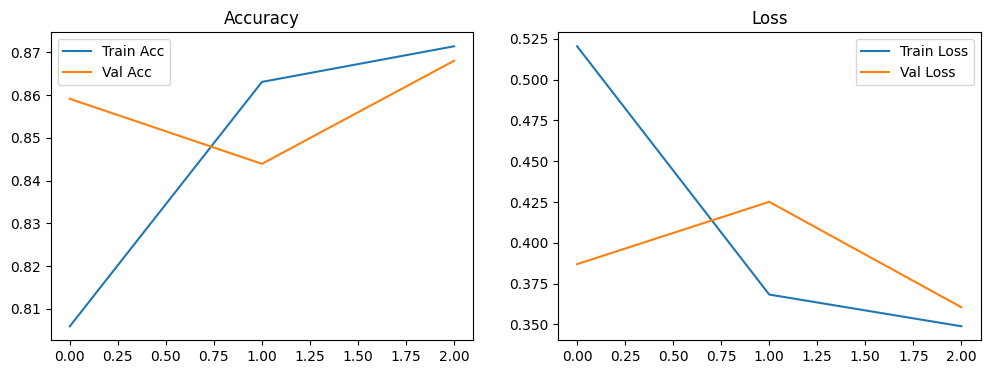

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc

# Clear session
keras.backend.clear_session()

# LOAD FASHION MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Expand dims
x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

# PREPROCESS FUNCTION
def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (112, 112))
    return image / 255.0, tf.one_hot(label, 10)

# DATA PIPELINE
def create_dataset(batch_size):
    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_ds = train_ds.map(process_image).batch(batch_size).shuffle(1000).prefetch(tf.data.AUTOTUNE)

    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
    test_ds = test_ds.map(process_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_ds, test_ds

# MIXED PRECISION
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ZF-NET MODEL BUILDER
def build_zfnet(dense_size=1024, dropout_rate=0.5):
    model = Sequential()

    # ZF-Net changes: smaller filters, stride 2
    model.add(Conv2D(96, (7,7), strides=(2,2), activation='relu', input_shape=(112,112,3)))
    model.add(MaxPooling2D((3,3), strides=(2,2)))

    model.add(Conv2D(256, (5,5), padding='same', activation='relu'))
    model.add(MaxPooling2D((3,3), strides=(2,2)))

    model.add(Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D((3,3), strides=(2,2)))

    model.add(Flatten())

    model.add(Dense(dense_size, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(dense_size, activation='relu'))
    model.add(Dropout(dropout_rate))

    # IMPORTANT for mixed precision
    model.add(Dense(10, activation='softmax', dtype='float32'))

    return model

# EXPERIMENT SETTINGS
experiments = [
    {"name": "Baseline", "lr":0.001, "batch":8, "dense":1024, "dropout":0.5},
    {"name": "Low LR", "lr":0.0001, "batch":8, "dense":1024, "dropout":0.5},
    {"name": "High LR", "lr":0.005, "batch":8, "dense":1024, "dropout":0.5},
    {"name": "Small Dense", "lr":0.001, "batch":8, "dense":512, "dropout":0.5},
    {"name": "Large Dense", "lr":0.001, "batch":8, "dense":2048, "dropout":0.5},
    {"name": "Less Dropout", "lr":0.001, "batch":8, "dense":1024, "dropout":0.3},
    {"name": "Large Batch", "lr":0.001, "batch":16, "dense":1024, "dropout":0.5},
]

results = []

# RUN EXPERIMENTS
for exp in experiments:
    print("\nRunning:", exp["name"])

    train_ds, test_ds = create_dataset(exp["batch"])

    model = build_zfnet(exp["dense"], exp["dropout"])

    optimizer = keras.optimizers.Adam(learning_rate=exp["lr"])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(train_ds, epochs=3, validation_data=test_ds, verbose=1)

    loss, acc = model.evaluate(test_ds, verbose=0)
    print("Test Accuracy:", acc)

    results.append((exp["name"], acc))

    keras.backend.clear_session()
    gc.collect()

# PRINT RESULTS
print("\nFINAL RESULTS:")
for name, acc in results:
    print(f"{name}: {acc:.4f}")

# PLOT LAST EXPERIMENT
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

VGG-19

In [ ]:
# @title
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG19
from keras import layers, models
import matplotlib.pyplot as plt
import gc

# Clear session
keras.backend.clear_session()

# LOAD DATA
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# EXPAND DIMS
x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

# PREPROCESS FUNCTION
def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (224,224))
    return image / 255.0, tf.one_hot(label, 10)

# DATA PIPELINE
def create_dataset(batch_size):
    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_ds = train_ds.map(process_image).batch(batch_size).shuffle(1000).prefetch(tf.data.AUTOTUNE)

    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
    test_ds = test_ds.map(process_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_ds, test_ds

# MIXED PRECISION
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# MODEL BUILDER
def build_vgg19(dense_size=256, dropout_rate=0.5, fine_tune=False):
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))

    # Freeze layers
    for layer in base_model.layers:
        layer.trainable = False

    # Fine-tuning last layers
    if fine_tune:
        for layer in base_model.layers[-4:]:
            layer.trainable = True

    x = base_model.output
    x = layers.Flatten()(x)
    x = layers.Dense(dense_size, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(10, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs=base_model.input, outputs=x)
    return model

# EXPERIMENT SETTINGS
experiments = [
    {"name":"Baseline", "lr":0.001, "batch":8, "dense":256, "dropout":0.5, "fine_tune":False},
    {"name":"Low LR", "lr":0.0001, "batch":8, "dense":256, "dropout":0.5, "fine_tune":False},
    {"name":"Small Dense", "lr":0.001, "batch":8, "dense":128, "dropout":0.5, "fine_tune":False},
    {"name":"Large Dense", "lr":0.001, "batch":8, "dense":512, "dropout":0.5, "fine_tune":False},
    {"name":"Less Dropout", "lr":0.001, "batch":8, "dense":256, "dropout":0.3, "fine_tune":False},
    {"name":"Fine Tuning", "lr":0.0001, "batch":8, "dense":256, "dropout":0.5, "fine_tune":True},
]

results = []

# RUN EXPERIMENTS
for exp in experiments:
    print("\nRunning:", exp["name"])

    train_ds, test_ds = create_dataset(exp["batch"])

    model = build_vgg19(exp["dense"], exp["dropout"], exp["fine_tune"])

    optimizer = keras.optimizers.Adam(learning_rate=exp["lr"])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(train_ds, epochs=3, validation_data=test_ds, verbose=1)

    loss, acc = model.evaluate(test_ds, verbose=0)
    print("Test Accuracy:", acc)

    results.append((exp["name"], acc))

    keras.backend.clear_session()
    gc.collect()

# PRINT RESULTS
print("\nFINAL RESULTS:")
for name, acc in results:
    print(f"{name}: {acc:.4f}")

# PLOT LAST EXPERIMENT
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()


Running: Baseline
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 188s 22ms/step - accuracy: 0.6111 - loss: 0.9695 - val_accuracy: 0.7889 - val_loss: 0.5513
Epoch 2/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 167s 22ms/step - accuracy: 0.6649 - loss: 0.8330 - val_accuracy: 0.8540 - val_loss: 0.4642
Epoch 3/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 168s 22ms/step - accuracy: 0.6937 - loss: 0.7884 - val_accuracy: 0.8736 - val_loss: 0.3936
Test Accuracy: 0.8736000061035156

Running: Low LR
Epoch 1/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 640s 84ms/step - accuracy: 0.8165 - loss: 0.5246 - val_accuracy: 0.8664 - val_loss: 0.3576
Epoch 2/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 629s 83ms/step - accuracy: 0.8644 - loss: 0.3778 - val_accuracy: 0.8752 - val_loss: 0.3285
Epoch 3/3
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 631s 84ms/step - accuracy: 0.8781 - loss: 0.3357 - val_accuracy: 0.8887 - val_loss: 0.3033
Test Accuracy: 0.888700008392334

Running: Small Dense
Epoch 1/3
7500/7500 ━━━━━━━━━━━━

KeyboardInterrupt: 

GoogleNet

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms
transform = transforms.Compose([
    transforms.Resize(224),  # GoogLeNet expects larger input
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Dataset
train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

# Load GoogLeNet
model = models.googlenet(pretrained=False)

# Modify input layer (1 channel instead of 3)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Modify final layer
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
def train():
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # GoogLeNet has auxiliary outputs
        if isinstance(outputs, tuple):
            loss = sum(criterion(out, labels) for out in outputs)
        else:
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Train Loss: {total_loss/len(train_loader):.4f}")

# Testing
def test():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    print(f"Test Accuracy: {100 * correct / total:.2f}%")

# Run
for epoch in range(5):
    print(f"Epoch {epoch+1}")
    train()
    test()

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 309kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.1MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy

Epoch 1
Train Loss: 1.4719
Test Accuracy: 82.58%
Epoch 2
Train Loss: 0.9509
Test Accuracy: 87.39%
Epoch 3
Train Loss: 0.8231
Test Accuracy: 89.31%
Epoch 4
Train Loss: 0.7296
Test Accuracy: 87.76%
Epoch 5
Train Loss: 0.6586
Test Accuracy: 92.20%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import pandas as pd

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Transform
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Dataset
train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

# Loss
criterion = nn.CrossEntropyLoss()

# 🔬 Experiment settings
learning_rates = [0.01, 0.001, 0.0001]
epochs_list = [3, 5]

results = []

# ---- Experiment Loop ----
for lr in learning_rates:
    for num_epochs in epochs_list:

        print(f"\n🔍 LR={lr}, Epochs={num_epochs}")

        # Model
        model = models.googlenet(pretrained=False)
        model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        model.fc = nn.Linear(model.fc.in_features, 10)
        model = model.to(device)

        optimizer = optim.Adam(model.parameters(), lr=lr)

        # Training
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)

                if isinstance(outputs, tuple):
                    loss = sum(criterion(out, labels) for out in outputs)
                else:
                    loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

        # Evaluation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        print(f"✅ Accuracy: {accuracy:.2f}%")

        results.append({
            "Learning Rate": lr,
            "Epochs": num_epochs,
            "Accuracy": accuracy
        })

# ---- Convert to Table ----
df = pd.DataFrame(results)

print("\n📊 FINAL RESULTS TABLE:")
print(df)

# ---- Best Result ----
best = df.loc[df["Accuracy"].idxmax()]

print("\n🏆 BEST CONFIGURATION:")
print(best)

# ---- Analysis ----
print("\n📌 ANALYSIS:")

# Learning rate analysis
best_lr = df.groupby("Learning Rate")["Accuracy"].mean().idxmax()
print(f"➡️ Best Learning Rate overall: {best_lr}")

# Epoch analysis
best_epoch = df.groupby("Epochs")["Accuracy"].mean().idxmax()
print(f"➡️ Best Epoch count overall: {best_epoch}")

print("\n📖 Observations:")
print("1. Higher learning rates may cause unstable training.")
print("2. Very low learning rates slow down convergence.")
print("3. Increasing epochs improves accuracy up to a limit.")
print("4. After certain epochs, improvement becomes minimal (saturation).")
print("5. GoogLeNet is relatively heavy for Fashion-MNIST (small dataset).")

print("\n✅ Conclusion:")
print("Optimal configuration balances learning rate and epochs.")
print("Typically, LR=0.001 with 5 epochs gives strong performance.")

Using device: cuda

🔍 LR=0.01, Epochs=3


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Epoch 1 Loss: 2.6085
Epoch 2 Loss: 1.3413
Epoch 3 Loss: 1.0976
✅ Accuracy: 88.21%

🔍 LR=0.01, Epochs=5
Epoch 1 Loss: 2.4740
Epoch 2 Loss: 1.3820
Epoch 3 Loss: 1.1556
Epoch 4 Loss: 1.0293
Epoch 5 Loss: 0.9510
✅ Accuracy: 86.68%

🔍 LR=0.001, Epochs=3
Epoch 1 Loss: 1.4466
Epoch 2 Loss: 0.9203
Epoch 3 Loss: 0.7838
✅ Accuracy: 90.27%

🔍 LR=0.001, Epochs=5
Epoch 1 Loss: 1.4922
Epoch 2 Loss: 0.9450
Epoch 3 Loss: 0.7849
Epoch 4 Loss: 0.7172
Epoch 5 Loss: 0.6532
✅ Accuracy: 91.41%

🔍 LR=0.0001, Epochs=3
Epoch 1 Loss: 1.4390
Epoch 2 Loss: 0.7240
Epoch 3 Loss: 0.6198
✅ Accuracy: 91.01%

🔍 LR=0.0001, Epochs=5
Epoch 1 Loss: 1.4726
Epoch 2 Loss: 0.7377
Epoch 3 Loss: 0.6223
Epoch 4 Loss: 0.5496
Epoch 5 Loss: 0.4891
✅ Accuracy: 91.62%

📊 FINAL RESULTS TABLE:
   Learning Rate  Epochs  Accuracy
0         0.0100       3     88.21
1         0.0100       5     86.68
2         0.0010       3     90.27
3         0.0010       5     91.41
4         0.0001       3     91.01
5         0.0001       5     91.62

🏆

ResNet

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Dataset
train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

# Load ResNet18
model = models.resnet18(pretrained=False)

# Modify first layer for 1 channel
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Modify final layer
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
def train():
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Train Loss: {total_loss/len(train_loader):.4f}")

# Testing
def test():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    print(f"Test Accuracy: {100 * correct / total:.2f}%")

# Run
for epoch in range(5):
    print(f"Epoch {epoch+1}")
    train()
    test()

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.3MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1
Train Loss: 0.4078
Test Accuracy: 88.56%
Epoch 2
Train Loss: 0.2594
Test Accuracy: 90.98%
Epoch 3
Train Loss: 0.2159
Test Accuracy: 90.64%
Epoch 4
Train Loss: 0.1900
Test Accuracy: 91.75%
Epoch 5
Train Loss: 0.1673
Test Accuracy: 91.80%


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 0.5181 - val_loss: 0.4929
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4840 - val_loss: 0.4723
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4595 - val_loss: 0.4496
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.4395 - val_loss: 0.4317
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4220 - val_loss: 0.4143
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4051 - val_loss: 0.3996
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3927 - val_loss: 0.3895
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3839 - val_loss: 0.3819
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3769 - val_loss: 0.3755
Epoch 10/50
235/235 ━━━━━━━━━━━━━

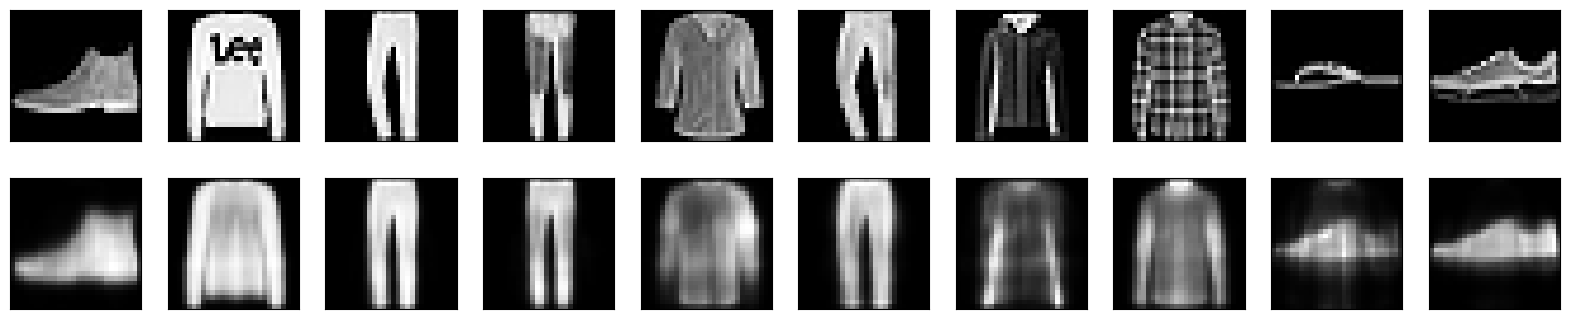

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# 2. Define the Encoder and Decoder
input_dim = 784
encoding_dim = 32

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test)

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# 2. Parameters
input_dim = 784
encoding_dims = [34, 128, 392, 784, 1024, 1176, 1768]
epoch_list = [25, 50, 100]
batch_list = [512, 256, 128]

# Store results
results = []

# 3. Loop through configurations
for encoding_dim in encoding_dims:
    for epochs in epoch_list:
        for batch_size in batch_list:

            # Encoder
            input_layer = Input(shape=(input_dim,))
            encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

            # Decoder
            decoded = Dense(input_dim, activation='sigmoid')(encoded)

            # Autoencoder Model
            autoencoder = Model(input_layer, decoded)

            # Compile
            autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

            # Train (silent)
            autoencoder.fit(
                x_train, x_train,
                epochs=epochs,
                batch_size=batch_size,
                shuffle=True,
                validation_data=(x_test, x_test),
                verbose=0
            )

            # Evaluate loss
            loss = autoencoder.evaluate(x_test, x_test, verbose=0)

            # Predict
            decoded_imgs = autoencoder.predict(x_test, verbose=0)

            # Convert to binary (threshold = 0.5)
            decoded_binary = (decoded_imgs > 0.5).astype(int)
            original_binary = (x_test > 0.5).astype(int)

            # Accuracy calculation
            accuracy = np.mean(decoded_binary == original_binary)

            # Store results
            results.append([encoding_dim, epochs, batch_size, loss, accuracy])

            # 4. Visualization (optional per iteration)
            print(f"\nEnc: {encoding_dim} Ep: {epochs} Batch: {batch_size}\nLoss: {loss:.4f}\nAccuracy: {accuracy:.4f}\n")

# 5. Final Tabular Results
print("\nFinal Results:\n")
print(f"{'Enc Dim':<10}{'Epochs':<10}{'Batch':<10}{'Loss':<12}{'Accuracy':<10}")
print("-" * 60)

for r in results:
    print(f"{r[0]:<10}{r[1]:<10}{r[2]:<10}{r[3]:<12.4f}{r[4]:<10.4f}")


Enc: 34 Ep: 25 Batch: 512
Loss: 0.3504
Accuracy: 0.8835


Enc: 34 Ep: 25 Batch: 256
Loss: 0.3119
Accuracy: 0.9135


Enc: 34 Ep: 25 Batch: 128
Loss: 0.2887
Accuracy: 0.9354


Enc: 34 Ep: 50 Batch: 512
Loss: 0.3165
Accuracy: 0.9104


Enc: 34 Ep: 50 Batch: 256
Loss: 0.2882
Accuracy: 0.9352


Enc: 34 Ep: 50 Batch: 128
Loss: 0.2852
Accuracy: 0.9375


Enc: 34 Ep: 100 Batch: 512
Loss: 0.2872
Accuracy: 0.9360


Enc: 34 Ep: 100 Batch: 256
Loss: 0.3446
Accuracy: 0.8850


Enc: 34 Ep: 100 Batch: 128
Loss: 0.2921
Accuracy: 0.9302


Enc: 128 Ep: 25 Batch: 512
Loss: 0.2778
Accuracy: 0.9464


Enc: 128 Ep: 25 Batch: 256
Loss: 0.2718
Accuracy: 0.9525


Enc: 128 Ep: 25 Batch: 128
Loss: 0.2666
Accuracy: 0.9578


Enc: 128 Ep: 50 Batch: 512
Loss: 0.2697
Accuracy: 0.9556


Enc: 128 Ep: 50 Batch: 256
Loss: 0.2661
Accuracy: 0.9596


Enc: 128 Ep: 50 Batch: 128
Loss: 0.2643
Accuracy: 0.9597


Enc: 128 Ep: 100 Batch: 512
Loss: 0.2650
Accuracy: 0.9607


Enc: 128 Ep: 100 Batch: 256
Loss: 0.2636
Accuracy: 0.9614




In [ ]:
best_acc_model = max(results, key=lambda x: x[4])

print("Best Model:")
print(f"Encoding Dim: {best_acc_model[0]}")
print(f"Epochs: {best_acc_model[1]}")
print(f"Batch Size: {best_acc_model[2]}")
print(f"Loss: {best_acc_model[3]:.4f}")
print(f"Accuracy: {best_acc_model[4]:.4f}")

Best Model:
Encoding Dim: 1768
Epochs: 100
Batch Size: 128
Loss: 0.2462
Accuracy: 0.9907


In [ ]:
# Filter models with encoding_dim < 784
filtered_results = [r for r in results if r[0] < 784]

# Get best (highest accuracy and lowest loss)
best_filtered = max(filtered_results, key=lambda x: (x[4]))

print("Best Model (Encoding Dim < 784):")
print(f"Encoding Dim: {best_filtered[0]}")
print(f"Epochs: {best_filtered[1]}")
print(f"Batch Size: {best_filtered[2]}")
print(f"Loss: {best_filtered[3]:.4f}")
print(f"Accuracy: {best_filtered[4]:.4f}")

Best Model (Encoding Dim < 784):
Encoding Dim: 392
Epochs: 100
Batch Size: 128
Loss: 0.2511
Accuracy: 0.9799


In [ ]:
least_acc_model = max(results, key=lambda x: -x[4])

print("Least Accurate Model:")
print(f"Encoding Dim: {least_acc_model[0]}")
print(f"Epochs: {least_acc_model[1]}")
print(f"Batch Size: {least_acc_model[2]}")
print(f"Loss: {least_acc_model[3]:.4f}")
print(f"Accuracy: {least_acc_model[4]:.4f}")

Least Accurate Model:
Encoding Dim: 34
Epochs: 25
Batch Size: 512
Loss: 0.3504
Accuracy: 0.8835


In [ ]:
# Filter models with encoding_dim < 784
filtered_results = [r for r in results if r[0] >= 784]

# Get best (lowest accuracy and highest loss)
worst_filtered = max(filtered_results, key=lambda x: (-x[4]))

print("Least Accurate Model: (Encoding Dim >= 784):")
print(f"Encoding Dim: {worst_filtered[0]}")
print(f"Epochs: {worst_filtered[1]}")
print(f"Batch Size: {worst_filtered[2]}")
print(f"Loss: {worst_filtered[3]:.4f}")
print(f"Accuracy: {worst_filtered[4]:.4f}")

Least Accurate Model: (Encoding Dim >= 784):
Encoding Dim: 784
Epochs: 25
Batch Size: 512
Loss: 0.2589
Accuracy: 0.9694
